# Canny Edge Detection

Today we are going to be implementing the Canny edge detection algorithm!!! It is important to note that knowing how to do the code for the first couple cells is not very important since these are just basic visualizations used in my blog. Most of these were generated using AI so I think its more important to know what you want to code and how to prompt in a way to get that. The code for the actual algorithm however I think is very critical to understand if you want to know how this algorithm works on a fundamental level. I would not skimp out on neither the math nor the code (In the notebook there will be a clear sign when we are shifting into relevent code).

www.aryanjain.work/blog/harris-corner-detection

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

(600, 868, 3)


Text(0.5, 1.0, 'Building')

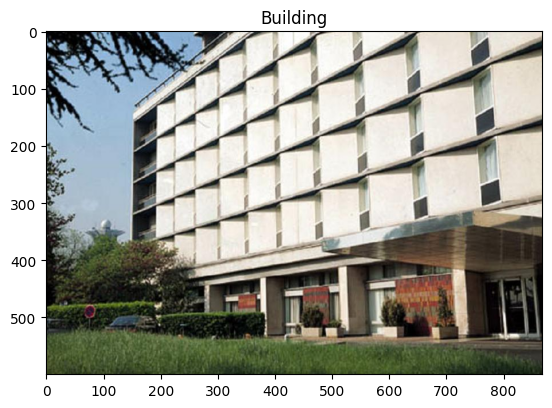

In [3]:
# Load the image we are going to be using for edge detection and display it

img = cv2.imread("../data/canny-edge-detector/building.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.shape)
plt.imshow(img)
plt.title("Building")

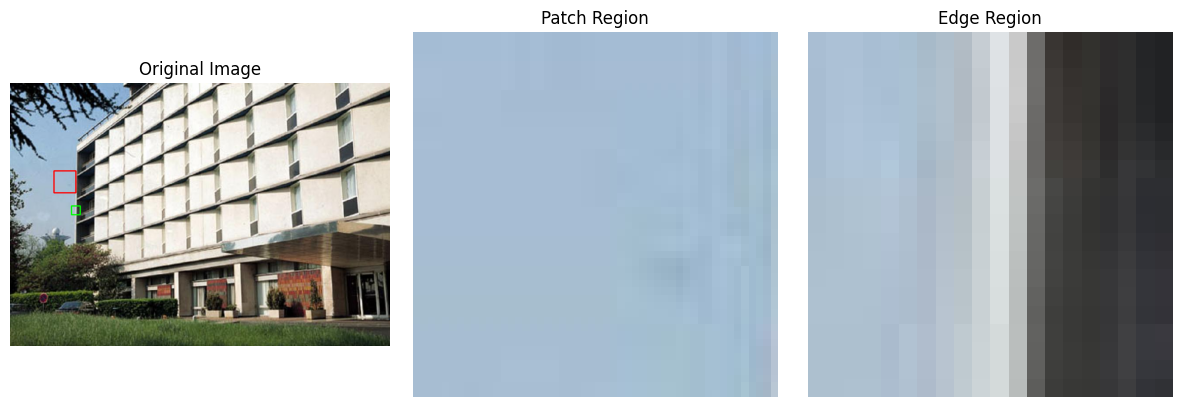

In [4]:
# Images follow this format since the y is represented by the rows: img[y,x]

patch = img[200:250, 100:150]

edge = img[280:300, 140:160]

img_boxes = img.copy()
cv2.rectangle(img_boxes, (100,200), (150,250), (255,0,0), 2)
cv2.rectangle(img_boxes, (140,280), (160,300), (0,255,0), 2)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_boxes)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(patch)
plt.title("Patch Region")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edge)
plt.title("Edge Region")
plt.axis("off")

plt.tight_layout()

plt.savefig("../outputs/canny-edge-detection/patch_vs_edge.png", bbox_inches="tight")

plt.show()

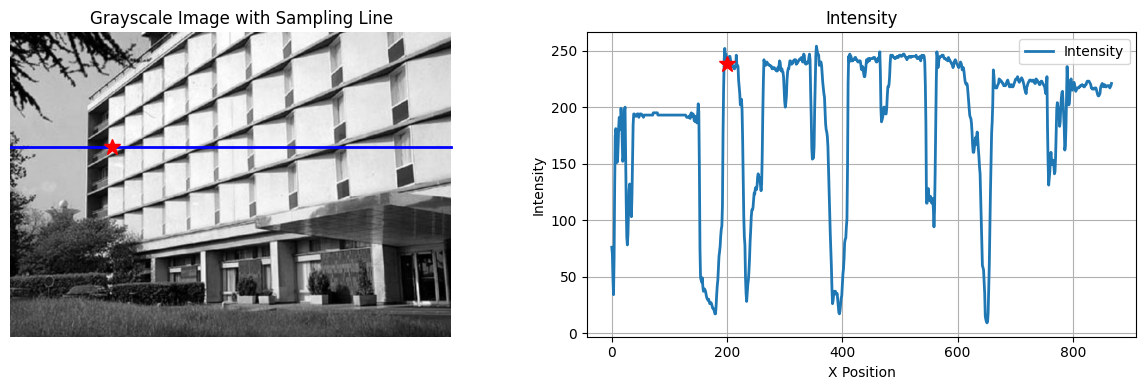

In [5]:
# Look at intensity values along a strip of pixels

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

y = 225
x_start = 0
x_end = 868

intensities = gray_img[y, x_start:x_end]
x_vals = np.arange(x_start, x_end)

line = np.linspace(intensities[0], intensities[-1], len(intensities))

px, py = 200, 225
intensity_point = gray_img[py, px]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].imshow(gray_img, cmap='gray')
axs[0].plot([x_start, x_end], [y, y], color='blue', linewidth=2)
axs[0].plot(px, py, marker='*', color='red', markersize=12)
axs[0].set_title("Grayscale Image with Sampling Line")
axs[0].axis("off")

axs[1].plot(x_vals, intensities, label="Intensity", linewidth=2)

axs[1].plot(px, gray_img[y, px], marker='*', color='red', markersize=12)

axs[1].set_title(f"Intensity")
axs[1].set_xlabel("X Position")
axs[1].set_ylabel("Intensity")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()

plt.savefig("../outputs/canny-edge-detection/intensity.png", bbox_inches="tight")

plt.show()

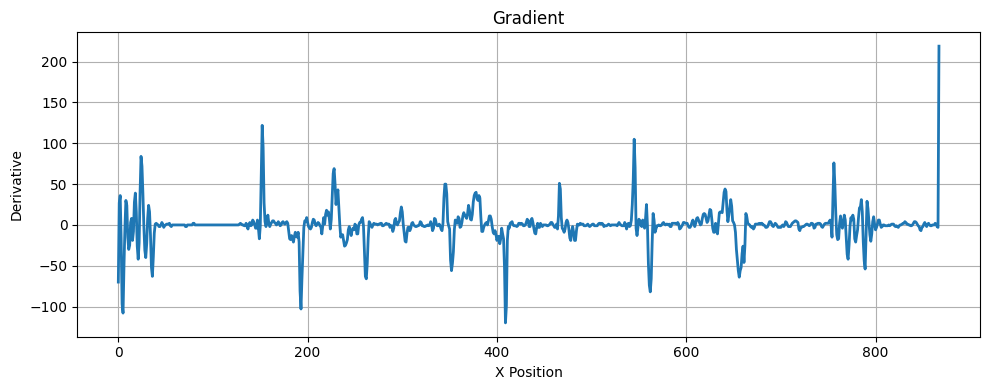

In [6]:
# Look at the gradient of intensity values along the previous strip of pixels

kernel = np.array([-1, 0, 1])

derivative = np.convolve(intensities, kernel, mode="same")

plt.figure(figsize=(10,4))
plt.plot(x_vals, derivative, linewidth=2)
plt.title("Gradient")
plt.xlabel("X Position")
plt.ylabel("Derivative")

plt.grid(True)
plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/gradient.png", bbox_inches="tight")
plt.show()

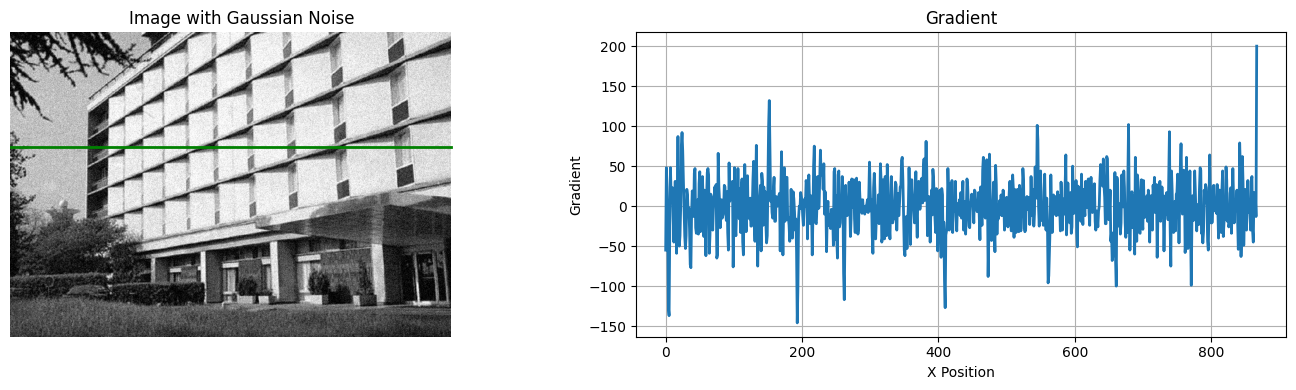

In [7]:
# Add Gaussian noise and look at what happens to the derivative

noise_sigma = 20
noise = np.random.normal(0, noise_sigma, gray_img.shape)

noisy_img = gray_img.astype(np.float32) + noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

noisy_intensities = noisy_img[y, x_start:x_end]

kernel = np.array([-1, 0, 1])
gradient = np.convolve(noisy_intensities, kernel, mode="same")

fig, axs = plt.subplots(1, 2, figsize=(14,4))

# Noisy image
axs[0].imshow(noisy_img, cmap="gray")
axs[0].plot([x_start, x_end], [y, y], color="green", linewidth=2)
axs[0].set_title("Image with Gaussian Noise")
axs[0].axis("off")

# Gradient plot
axs[1].plot(x_vals, gradient, linewidth=2)
axs[1].set_title(f"Gradient")
axs[1].set_xlabel("X Position")
axs[1].set_ylabel("Gradient")
axs[1].grid(True)

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/noisy_gradient.png", bbox_inches="tight")
plt.show()

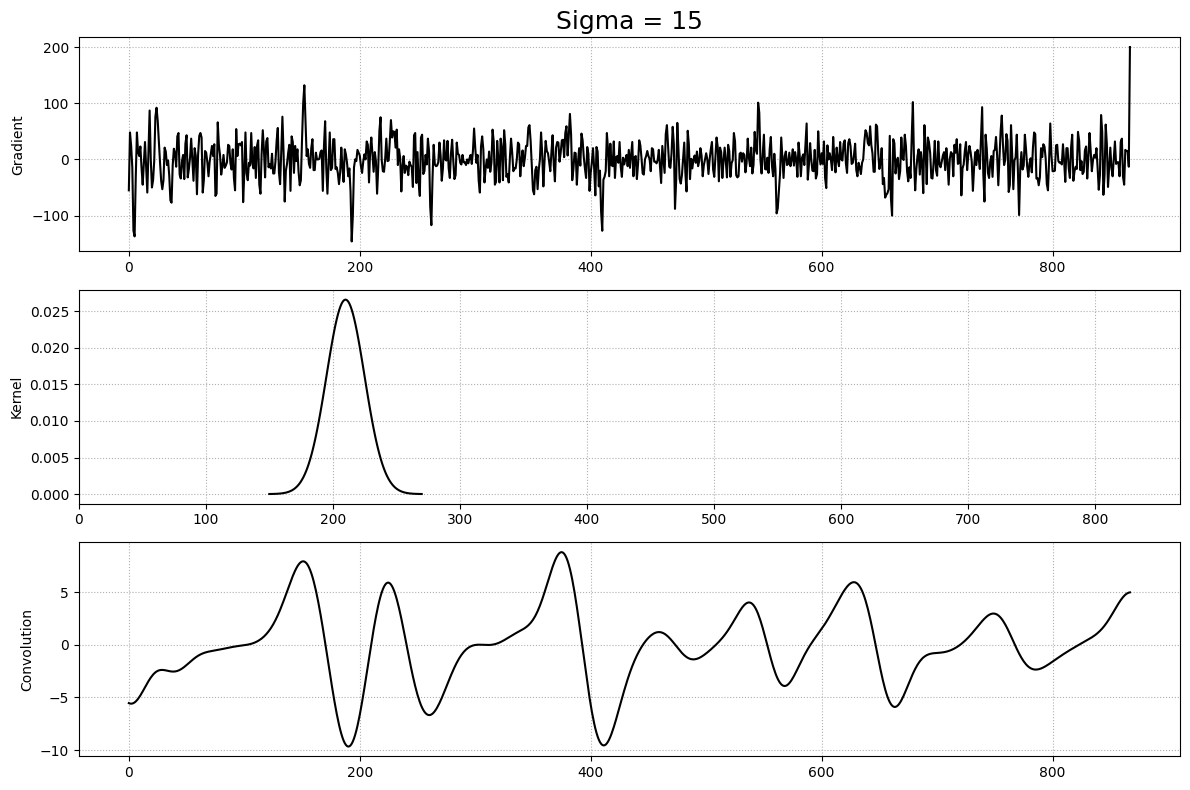

In [8]:
# Applying a Gaussian kernal to the gradient signal

# gradient is from the previous cell

sigma = 15
radius = int(4 * sigma)
k = np.arange(-radius, radius + 1)
gaussian = np.exp(-(k**2) / (2 * sigma**2))
gaussian = gaussian / gaussian.sum()

smoothed_gradient = np.convolve(gradient, gaussian, mode="same")

fig, axs = plt.subplots(3, 1, figsize=(12, 8))

axs[0].plot(x_vals, gradient, color="black", linewidth=1.5)
axs[0].set_title(f"Sigma = {sigma}", fontsize=18)
axs[0].set_ylabel("Gradient")
axs[0].grid(True, linestyle=":")

kernel_offset = 150
axs[1].plot(kernel_offset + np.arange(len(gaussian)), gaussian, color="black", linewidth=1.5)
axs[1].set_ylabel("Kernel")
axs[1].grid(True, linestyle=":")
axs[1].set_xlim(x_vals[0], x_vals[-1])

axs[2].plot(x_vals, smoothed_gradient, color="black", linewidth=1.5)
axs[2].set_ylabel("Convolution")
axs[2].grid(True, linestyle=":")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/gaussian_gradient_smoothing.png", bbox_inches="tight")
plt.show()

# Canny Edge Detection Algorithm Code

Now that we have analyzed the data lets begin actually coding out the algorithm. I will reinitalize the packages and variables so you can start reading from here down without confusion (think of this like two notebooks in one)!

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage

Text(0.5, 1.0, 'Building')

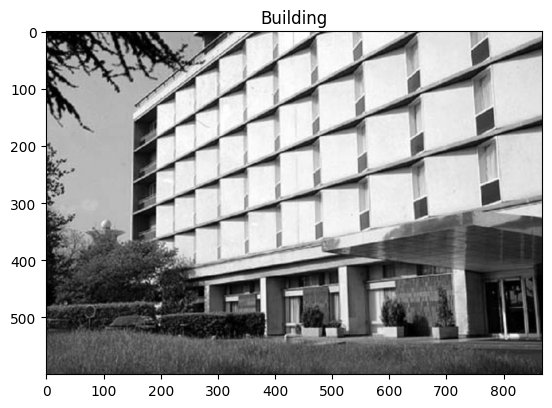

In [10]:
img = cv2.imread("../data/canny-edge-detector/building.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap = "gray")
plt.title("Building")


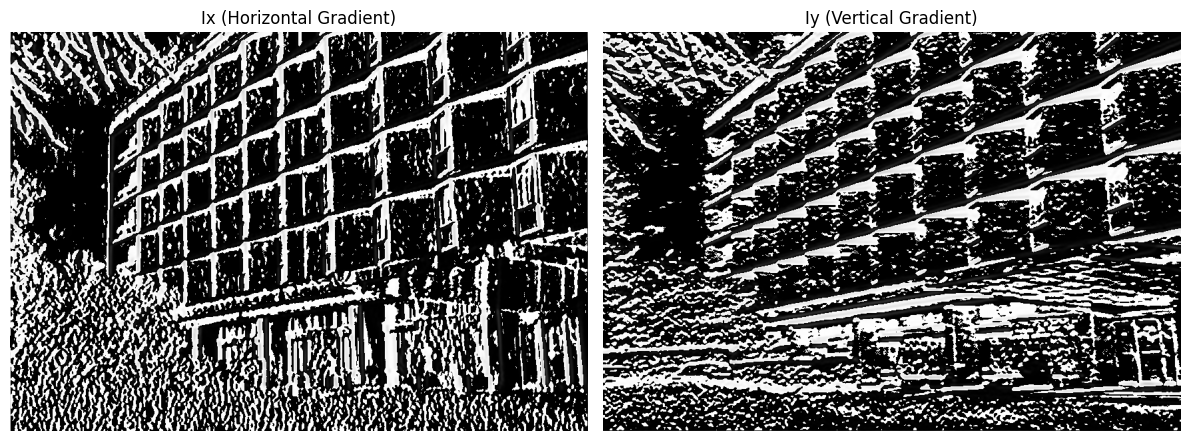

In [11]:
# We will now do the DoG

# Recall the first step is performing a Gaussian Blur
smooth_window_size = 7
blur = cv2.GaussianBlur(img, (smooth_window_size, smooth_window_size), 0)

# We can now create a Kernal and pass it through the image
kernel = np.array([-1, 0, 1], dtype=np.float32) / 2.0
Ix = ndimage.convolve1d(blur, kernel, axis=1, mode='constant')
Iy = ndimage.convolve1d(blur, kernel, axis=0, mode='constant')

# We have successfully computed the gradients and now we display the two
fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].imshow(Ix, cmap="gray")
axs[0].set_title("Ix (Horizontal Gradient)")
axs[0].axis("off")

axs[1].imshow(Iy, cmap="gray")
axs[1].set_title("Iy (Vertical Gradient)")
axs[1].axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/ix_iy.png", bbox_inches="tight")
plt.show()

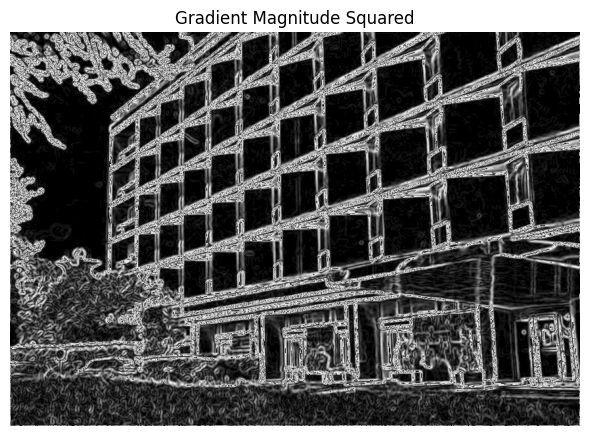

In [24]:
# We now can combine them and this will give us all the edges in the image
grad_mag = np.sqrt(np.square(Ix) + np.square(Iy))

plt.figure(figsize=(6,5))
plt.imshow(grad_mag, cmap="gray")
plt.title("Gradient Magnitude Squared")
plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/gradient_magnitude.png", bbox_inches="tight")
plt.show()

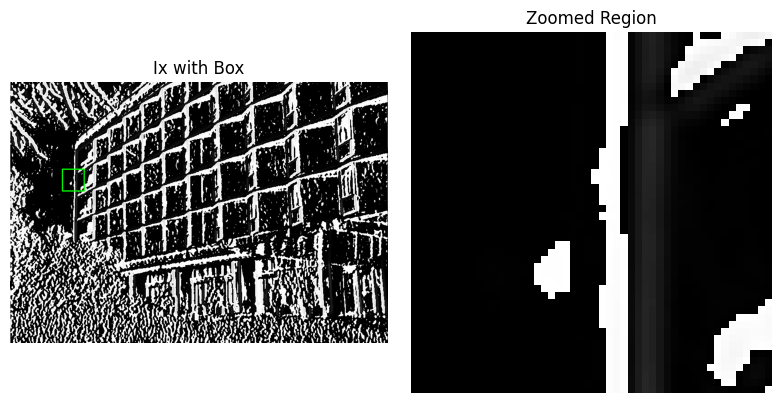

In [25]:
# We are going to be zooming into the Ix gradient to illustrate how in NMS we are thinning out edges as opposed to erasing them 
# code isn't too useful to understand but more why this matters in the blog

Ix_norm = (Ix - Ix.min()) / (Ix.max() - Ix.min())
Ix_norm = (Ix_norm * 255).astype(np.uint8)

Ix_rgb = cv2.cvtColor(Ix_norm, cv2.COLOR_GRAY2RGB)

Ix_box = Ix_rgb.copy()

x1, x2, y1, y2 = 120, 170, 200, 250
cv2.rectangle(Ix_box, (x1, y1), (x2, y2), (0, 255, 0), 2)

zoom_region = Ix_norm[y1:y2, x1:x2]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(Ix_box)
plt.title("Ix with Box")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(zoom_region, cmap="gray")
plt.title("Zoomed Region")
plt.axis("off")

plt.tight_layout()
plt.savefig("../outputs/canny-edge-detection/ix_thinning.png", bbox_inches="tight")
plt.show()